# 🚦 Near-Miss Incident Detection System

## AI/ML Technical Assessment | Computer Vision Challenge

**Author:** Osama Bsharat  
**Date:** 2026  
**Environment:** Google Colab (Free Tier) / CPU  

---

### System Architecture

```
Video Input ──► YOLO Detection ──► ByteTrack Tracking ──► Kalman Filter
                                                                  │
                              ┌───────────────────────────────────┘
                              ▼
Optical Flow ──► Flow Anomalies ──► Near-Miss Detection ──► Risk Scoring
                                           │
                              ┌────────────┴────────────┐
                              ▼                         ▼
                    False Positive Filter      Incident Grouping
                              │                         │
                              ▼                         ▼
                    Annotated Video          Dashboard + Report
```

### Key Technical Choices

| Component | Selection | Rationale |
|-----------|-----------|----------|
| **Detector** | YOLOv8 Nano (3.2M params) | Optimal CPU speed/accuracy |
| **Tracker** | ByteTrack | No ReID needed, robust to occlusions |
| **Trajectory** | 6-state Kalman Filter | Smooth velocity + acceleration estimation |
| **Optical Flow** | Farneback (dense) | Per-pixel motion for flow anomaly detection |
| **Risk Model** | Multi-criteria composite | Distance + TTC + vulnerability weighting |

### Table of Contents

1. [Setup & Configuration](#1)
2. [Video Acquisition & Inspection](#2)
3. [Object Detection & Tracking](#3)
4. [Kalman-Filtered Trajectory Analysis](#4)
5. [Optical Flow Analysis](#5)
6. [Near-Miss Detection & Risk Scoring](#6)
7. [Video Annotation](#7)
8. [Statistical Dashboard](#8)
9. [Report Generation](#9)
10. [Limitations & Future Work](#10)

In [1]:

import sys
print(sys.executable)


d:\Tatweer\FULL VERSION\near-miss-detection\env\Scripts\python.exe


In [36]:
# ════════════════════════════════════════════════════════
# 1.1  Import Modules
# ════════════════════════════════════════════════════════

import sys, os, warnings
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import HTML, display

warnings.filterwarnings('ignore')
np.random.seed(42)

sys.path.insert(0, os.path.abspath(r'D:\Tatweer\FULL VERSION\near-miss-detection'))

from src.config import PipelineConfig
from src.utils import (
    download_video, get_video_info, extract_sample_frames,
    analyze_tracking_quality, Timer
)
from src.detector import ObjectDetector
from src.tracker import TrajectoryAnalyzer
from src.near_miss import NearMissDetector
from src.optical_flow import OpticalFlowAnalyzer
from src.visualizer import VideoAnnotator, DashboardGenerator
from src.report import generate_html_report, export_json_results

print('All modules imported')
print(f'OpenCV: {cv2.__version__}')

All modules imported
OpenCV: 4.13.0


In [37]:
# ════════════════════════════════════════════════════════
# 1.2  Load Configuration
# ════════════════════════════════════════════════════════

cfg = PipelineConfig()
print(cfg.summary())

  Pipeline Configuration Summary
  Detector:    yolov8n.pt (conf=0.35)
  Tracker:     ByteTrack (history=30)
  Kalman:      6D state, σ_process=1.0
  Near-Miss:   D_high=60.0px, TTC_high=0.8s
  Filtering:   min_frames=3, merge_gap=10
  Opt. Flow:   interval=2, threshold=2.0
  Classes:     ['Pedestrian', 'Cyclist', 'Car', 'Motorcycle', 'Bus', 'Truck']


<a id="2"></a>
---
## 2. Video Loading & Inspection

Load the local traffic near-miss video and extract metadata for calibration.

In [38]:
# ════════════════════════════════════════════════════════
# 2.1  Load Local Video
# ════════════════════════════════════════════════════════

video_path = r'../inputs/Car missed it exit and causes two semi trucks to CRASH.mp4'
video_info = get_video_info(video_path)

print(f'\n📹 Video Info:')
for k, v in video_info.items():
    print(f'   {k}: {v}')


📹 Video Info:
   width: 1280
   height: 720
   fps: 20.0
   total_frames: 460
   duration_sec: 23.0
   duration_str: 0:00:23


In [ ]:
# ════════════════════════════════════════════════════════
# 2.2  Preview Sample Frames
# ════════════════════════════════════════════════════════

samples = extract_sample_frames(video_path, n_frames=6)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Sample Frames from Traffic Video', fontsize=16, fontweight='bold')

for ax, (idx, frame) in zip(axes.flat, samples):
    ax.imshow(frame)
    ax.set_title(f'Frame {idx} | t={idx/video_info["fps"]:.1f}s', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/sample_frames.png', dpi=150, bbox_inches='tight')
plt.show()

<a id="3"></a>
---
## 3. Object Detection & Tracking

### YOLOv8 Nano + ByteTrack

**YOLOv8 Nano** provides the optimal balance of detection accuracy and CPU inference speed:
- 3.2M parameters (7x smaller than YOLOv8s)
- ~30ms/frame on CPU (meets <5min total inference requirement)
- mAP@50: 37.3 on COCO — sufficient for traffic objects

**ByteTrack** handles multi-object tracking:
- Two-stage IoU association (high-confidence + low-confidence pass)
- Handles occlusions by re-associating low-confidence detections
- No separate ReID model required → minimal CPU overhead
- Maintains stable track IDs across frames

In [9]:
# ════════════════════════════════════════════════════════
# 3.1  Run Detection + Tracking Pipeline
# ════════════════════════════════════════════════════════

detector = ObjectDetector(cfg)
detector.initialize()

frame_results = detector.run(video_path, video_info['fps'])

  🔄 Loading yolov8n.pt...
  ✅ Model loaded: 3,151,904 parameters
  🔄 Running detection + tracking...
    Frame 100 | 19.1 FPS | 1 objects
    Frame 200 | 18.6 FPS | 1 objects
    Frame 300 | 17.2 FPS | 1 objects
    Frame 400 | 16.4 FPS | 0 objects
  ⏱ Detection + Tracking: 28.8s
  ✅ Processed 458 frames at 15.9 FPS


In [1]:
import torch, ultralytics
print("torch:", torch.__version__)
print("ultralytics:", ultralytics.__version__)

torch: 2.5.1+cpu
ultralytics: 8.2.0


In [40]:
# ════════════════════════════════════════════════════════
# 3.2  Detection & Tracking Statistics
# ════════════════════════════════════════════════════════

tracking_stats = analyze_tracking_quality(frame_results)

print('Detection & Tracking Statistics:')
print(f'   Total frames:         {tracking_stats["total_frames"]}')
print(f'   Total detections:     {tracking_stats["total_detections"]:,}')
print(f'   Unique tracks:        {tracking_stats["unique_tracks"]}')
print(f'   Avg objects/frame:    {tracking_stats["avg_objects_per_frame"]:.1f} ± {tracking_stats["objects_per_frame_std"]:.1f}')
print(f'   Avg track length:     {tracking_stats["avg_track_length"]:.0f} frames')
print(f'   Longest track:        {tracking_stats["longest_track"]} frames')
print(f'   Avg confidence:       {tracking_stats["avg_confidence"]:.3f}')
print(f'\n   Class Distribution:')
for cls, cnt in sorted(tracking_stats['class_counts'].items(), key=lambda x: -x[1]):
    print(f'     {cls}: {cnt:,}')

Detection & Tracking Statistics:
   Total frames:         458
   Total detections:     542
   Unique tracks:        12
   Avg objects/frame:    1.2 ± 0.8
   Avg track length:     38 frames
   Longest track:        261 frames
   Avg confidence:       0.625

   Class Distribution:
     Car: 441
     Bus: 72
     Pedestrian: 16
     Truck: 13


<a id="4"></a>
---
## 4. Kalman-Filtered Trajectory Analysis

### 6-State Kalman Filter

We use a **constant acceleration model** with state vector `[x, y, vx, vy, ax, ay]`:

- **Position (x, y)**: centroid coordinates in pixel space
- **Velocity (vx, vy)**: estimated from position changes, filtered for noise
- **Acceleration (ax, ay)**: captures braking/swerving dynamics

This is superior to simple frame-to-frame differencing because:
1. **Noise reduction**: Detection jitter is smoothed by the Kalman gain
2. **Occlusion handling**: Predicts position during tracking gaps
3. **Acceleration awareness**: Captures sudden speed changes (critical for near-misses)
4. **Trajectory prediction**: Forward propagation for TTC estimation

In [43]:
# ════════════════════════════════════════════════════════
# 4.1  Build Kalman-Filtered Track Histories
# ════════════════════════════════════════════════════════

trajectory_analyzer = TrajectoryAnalyzer(cfg)
track_histories = trajectory_analyzer.build(frame_results)

# Show velocity statistics for top tracks
print(f'\nTop 10 tracks by duration:')
sorted_tracks = sorted(
    track_histories.items(), 
    key=lambda x: x[1].total_frames, 
    reverse=True
)[:10]

print(f'{"ID":>5} | {"Class":>12} | {"Frames":>7} | {"Avg Speed":>10} | {"Kalman Vel":>12}')
print('-' * 60)
for tid, hist in sorted_tracks:
    kv = hist.kalman_velocity
    print(f'{tid:>5} | {hist.class_name:>12} | {hist.total_frames:>7} | '
          f'{hist.speed:>9.2f}px/f | ({kv[0]:>5.1f}, {kv[1]:>5.1f})')

  ✅ Built 12 track histories with Kalman filtering

Top 10 tracks by duration:
   ID |        Class |  Frames |  Avg Speed |   Kalman Vel
------------------------------------------------------------
    3 |          Car |     261 |      3.66px/f | ( -3.5,   1.2)
    7 |          Car |      55 |     10.45px/f | (  2.0,  10.3)
    5 |          Bus |      31 |     24.53px/f | (  5.8,  23.8)
    6 |          Bus |      27 |     10.38px/f | ( -9.7,  -3.7)
    8 |          Car |      17 |     21.50px/f | ( 18.3,  11.2)
   11 |          Car |      17 |      3.24px/f | ( -2.1,   2.5)
   12 |        Truck |      13 |     13.69px/f | (-13.3,  -3.3)
    2 |          Car |      11 |     40.26px/f | ( 34.3,  21.0)
    9 |          Car |       9 |      4.38px/f | ( -3.2,  -3.0)
    4 |          Car |       5 |      9.73px/f | ( -9.6,  -1.5)


<a id="5"></a>
---
## 5. Optical Flow Analysis (Bonus)

### Farneback Dense Optical Flow

Dense optical flow provides **scene-level motion analysis** independent of the object tracker:

1. **Motion validation**: Cross-reference flow-based speed with Kalman-estimated velocity
2. **Anomaly detection**: Sudden changes in scene flow magnitude often correlate with evasive actions (braking, swerving)
3. **Untracked motion**: Detects motion from objects the detector may have missed

Flow is computed every 2 frames to balance accuracy and CPU performance.

In [44]:
# ════════════════════════════════════════════════════════
# 5.1  Compute Dense Optical Flow
# ════════════════════════════════════════════════════════

flow_analyzer = OpticalFlowAnalyzer(cfg)
flow_maps = flow_analyzer.compute(video_path, frame_results)

  🔄 Computing optical flow (interval=2)...
    Computed flow for 50 frames...
    Computed flow for 100 frames...
    Computed flow for 150 frames...
    Computed flow for 200 frames...
  ⏱ Optical Flow: 43.8s
  ✅ Optical flow computed for 228 frames


In [ ]:
# ════════════════════════════════════════════════════════
# 5.2  Detect Flow Anomalies
# ════════════════════════════════════════════════════════

flow_anomalies = flow_analyzer.detect_flow_anomalies(threshold_multiplier=2.5)

if flow_anomalies:
    print(f'\nFlow Anomaly Details:')
    for a in flow_anomalies[:10]:
        t = a['frame_idx'] / video_info['fps']
        print(f'   Frame {a["frame_idx"]} (t={t:.1f}s) | '
              f'Magnitude={a["magnitude"]:.2f} | '
              f'Z-score={a["z_score"]:.1f} | '
              f'Motion area={a["motion_area"]*100:.1f}%')
else:
    print('   No significant flow anomalies detected.')

  ⚠ Found 3 flow anomaly frames (threshold=2.74)

⚠ Flow Anomaly Details:
   Frame 192 (t=9.6s) | Magnitude=2.75 | Z-score=2.5 | Motion area=15.2%
   Frame 210 (t=10.5s) | Magnitude=2.95 | Z-score=2.8 | Motion area=14.7%
   Frame 370 (t=18.5s) | Magnitude=2.76 | Z-score=2.5 | Motion area=13.2%


<a id="6"></a>
---
## 6. Near-Miss Detection & Risk Scoring

### Multi-Criteria Risk Assessment

Each object pair is evaluated using:

| Criterion | Method | Weight |
|-----------|--------|--------|
| **Proximity** | Edge-to-edge bbox distance | 40% |
| **TTC** | Kalman-predicted closing speed | 60% |
| **Vulnerability** | Pedestrian/cyclist multiplier (×1.3) | Modifier |

### Risk Classification

| Level | Distance | TTC | Description |
|-------|----------|-----|-------------|
| **HIGH** | < 60px | < 0.8s | Imminent collision, narrowly avoided |
| **MEDIUM** | < 120px | < 1.5s | Dangerous, evasive action needed |
| **LOW** | < 200px | < 3.0s | Warning zone, precautionary |

### False Positive Reduction (3 Layers)

1. **Temporal persistence**: Must persist ≥ 3 consecutive frames
2. **Area threshold**: Bounding boxes < 400px² excluded
3. **Incident merging**: Events within 10-frame gap consolidated

In [14]:
# ════════════════════════════════════════════════════════
# 6.1  Detect Near-Miss Events
# ════════════════════════════════════════════════════════

near_miss_detector = NearMissDetector(cfg, trajectory_analyzer)
raw_events = near_miss_detector.detect(frame_results, video_info['fps'])

  ✅ Raw near-miss events: 113


In [ ]:
# ════════════════════════════════════════════════════════
# 6.2  Group Into Incidents (with False Positive Filtering)
# ════════════════════════════════════════════════════════

incidents = near_miss_detector.group_incidents(raw_events)

# Summary
risk_counts = defaultdict(int)
for inc in incidents:
    risk_counts[inc.max_risk_level] += 1

print(f'\nIncident Summary:')
for level in ['HIGH', 'MEDIUM', 'LOW']:
    print(f'   {level}: {risk_counts[level]} incidents')

print(f'\n   Top 5 Most Critical:')
for inc in sorted(incidents, key=lambda i: -i.max_risk_score)[:5]:
    ttc = f'{inc.min_ttc:.2f}s' if inc.min_ttc != float('inf') else 'N/A'
    print(f'   #{inc.incident_id} | t={inc.start_time:.1f}-{inc.end_time:.1f}s | '
          f'{inc.max_risk_level} ({inc.max_risk_score:.2f}) | '
          f'D={inc.min_distance:.0f}px | TTC={ttc} | {inc.involved_classes}')

  ✅ 6 incidents (from 113 raw events, 95% filtered)

📋 Incident Summary:
   HIGH: 3 incidents
   MEDIUM: 3 incidents
   LOW: 0 incidents

   Top 5 Most Critical:
   #1 | t=11.1-12.3s | MEDIUM (0.56) | D=69px | TTC=1.52s | {'Bus', 'Car'}
   #5 | t=13.7-13.9s | MEDIUM (0.41) | D=252px | TTC=0.93s | {'Car'}
   #0 | t=8.0-8.9s | HIGH (0.40) | D=0px | TTC=N/A | {'Bus', 'Car'}
   #3 | t=11.3-12.3s | HIGH (0.37) | D=17px | TTC=N/A | {'Bus', 'Car'}
   #2 | t=11.3-12.8s | HIGH (0.35) | D=25px | TTC=N/A | {'Car'}


<a id="7"></a>
---
## 7. Video Annotation

Generate annotated output video with:
- Class-colored bounding boxes with track IDs
- Trajectory trails (last 20 positions)
- Risk indicators with connecting lines
- Kalman-predicted collision points
- Real-time HUD (timestamp, incident counter, risk badge)
- Optical flow overlay (bottom-right corner)

In [16]:
# ════════════════════════════════════════════════════════
# 7.1  Build Frame-Event Map
# ════════════════════════════════════════════════════════

frame_event_map = defaultdict(list)
for inc in incidents:
    for evt in inc.events:
        frame_event_map[evt.frame_idx].append(evt)

print(f'{len(frame_event_map)} frames with active events')

65 frames with active events


In [17]:
# ════════════════════════════════════════════════════════
# 7.2  Generate Annotated Video
# ════════════════════════════════════════════════════════

annotator = VideoAnnotator(cfg)
output_video = annotator.annotate(
    video_path, cfg.output_video,
    frame_results, dict(frame_event_map),
    track_histories, incidents,
    flow_analyzer=flow_analyzer
)

  🎬 Generating annotated video...
    Annotated 200/460 frames...
    Annotated 400/460 frames...
  ⏱ Video Annotation: 7.3s
  ✅ Saved: annotated_near_miss.mp4 (7.2 MB)


In [18]:
# ════════════════════════════════════════════════════════
# 7.3  Extract Peak Moment Frames
# ════════════════════════════════════════════════════════

dashboard_gen = DashboardGenerator(cfg)
dashboard_gen.extract_peak_frames(cfg.output_video, incidents)

  ✅ Peak moments saved: peak_moments.png


<a id="8"></a>
---
## 8. Statistical Dashboard

  ✅ Dashboard saved: dashboard.png


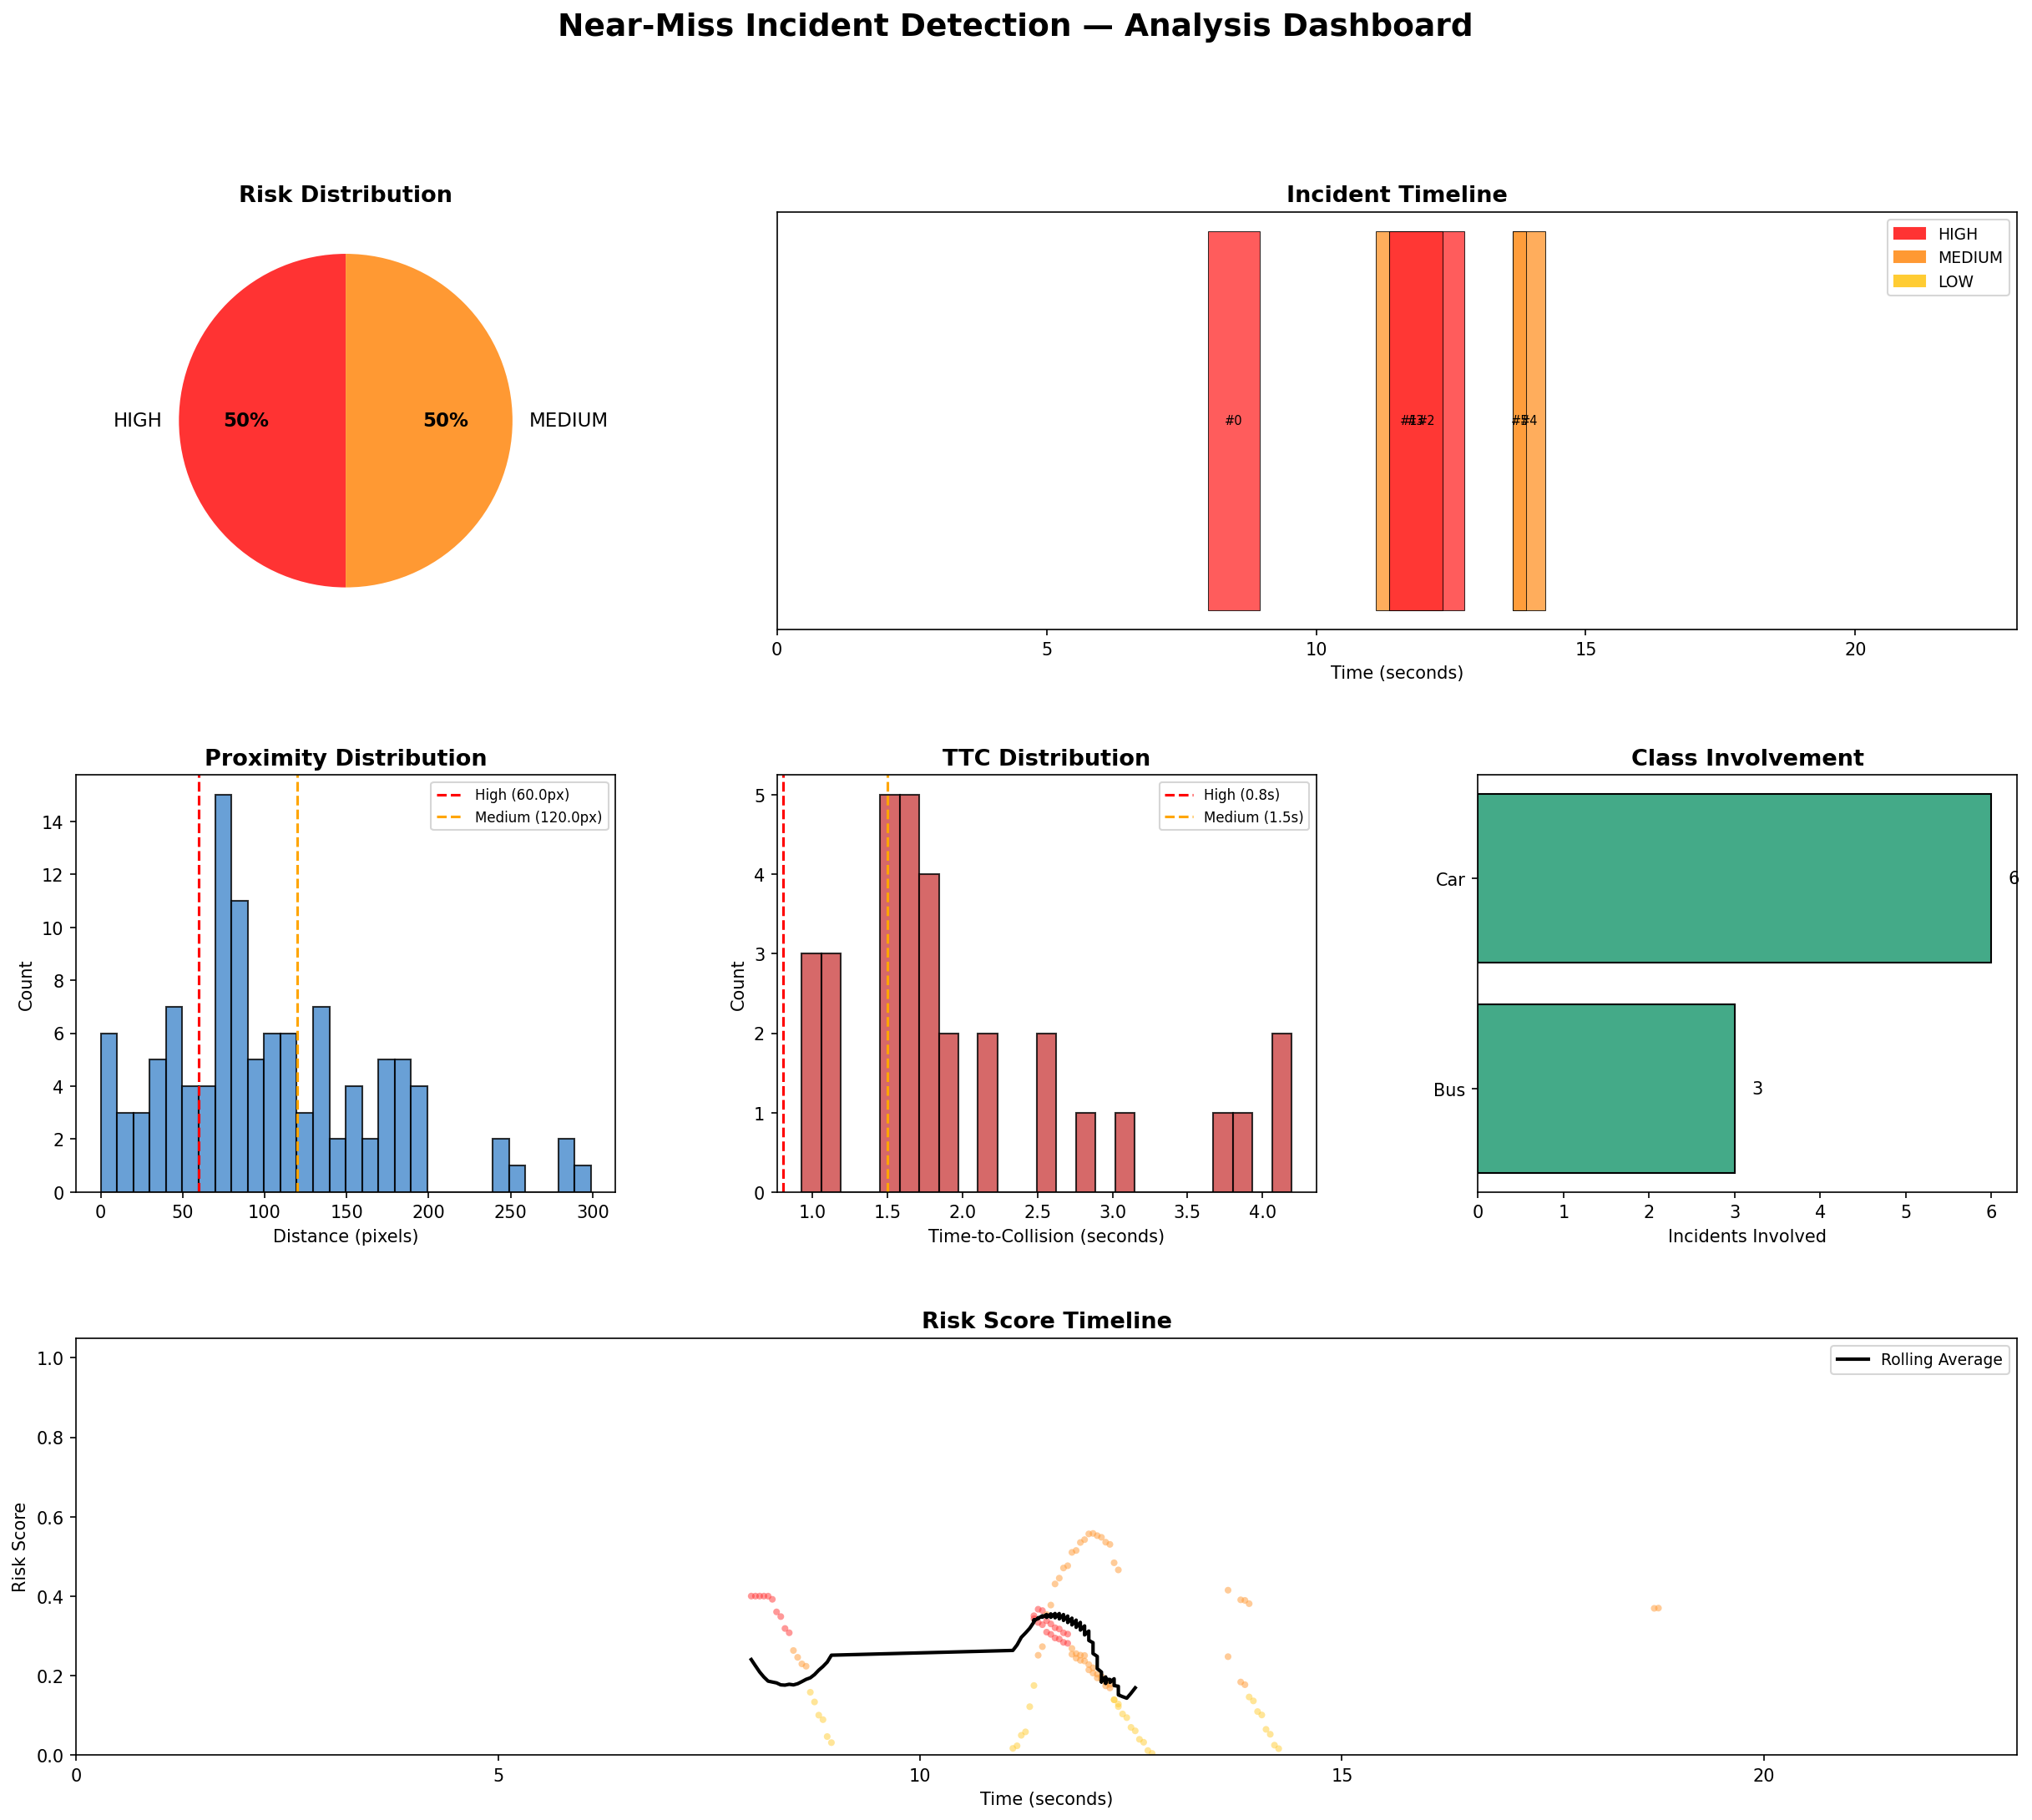

In [ ]:
# ════════════════════════════════════════════════════════
# 8.1  Main Analysis Dashboard (6 Panels)
# ════════════════════════════════════════════════════════

dashboard_gen.create(
    incidents, raw_events, tracking_stats, video_info,
    flow_stats=flow_analyzer.scene_flow_stats
)

# Display inline
from IPython.display import Image as IPImage
display(IPImage('../outputs/dashboard.png'))

  ✅ Flow dashboard saved: flow_dashboard.png


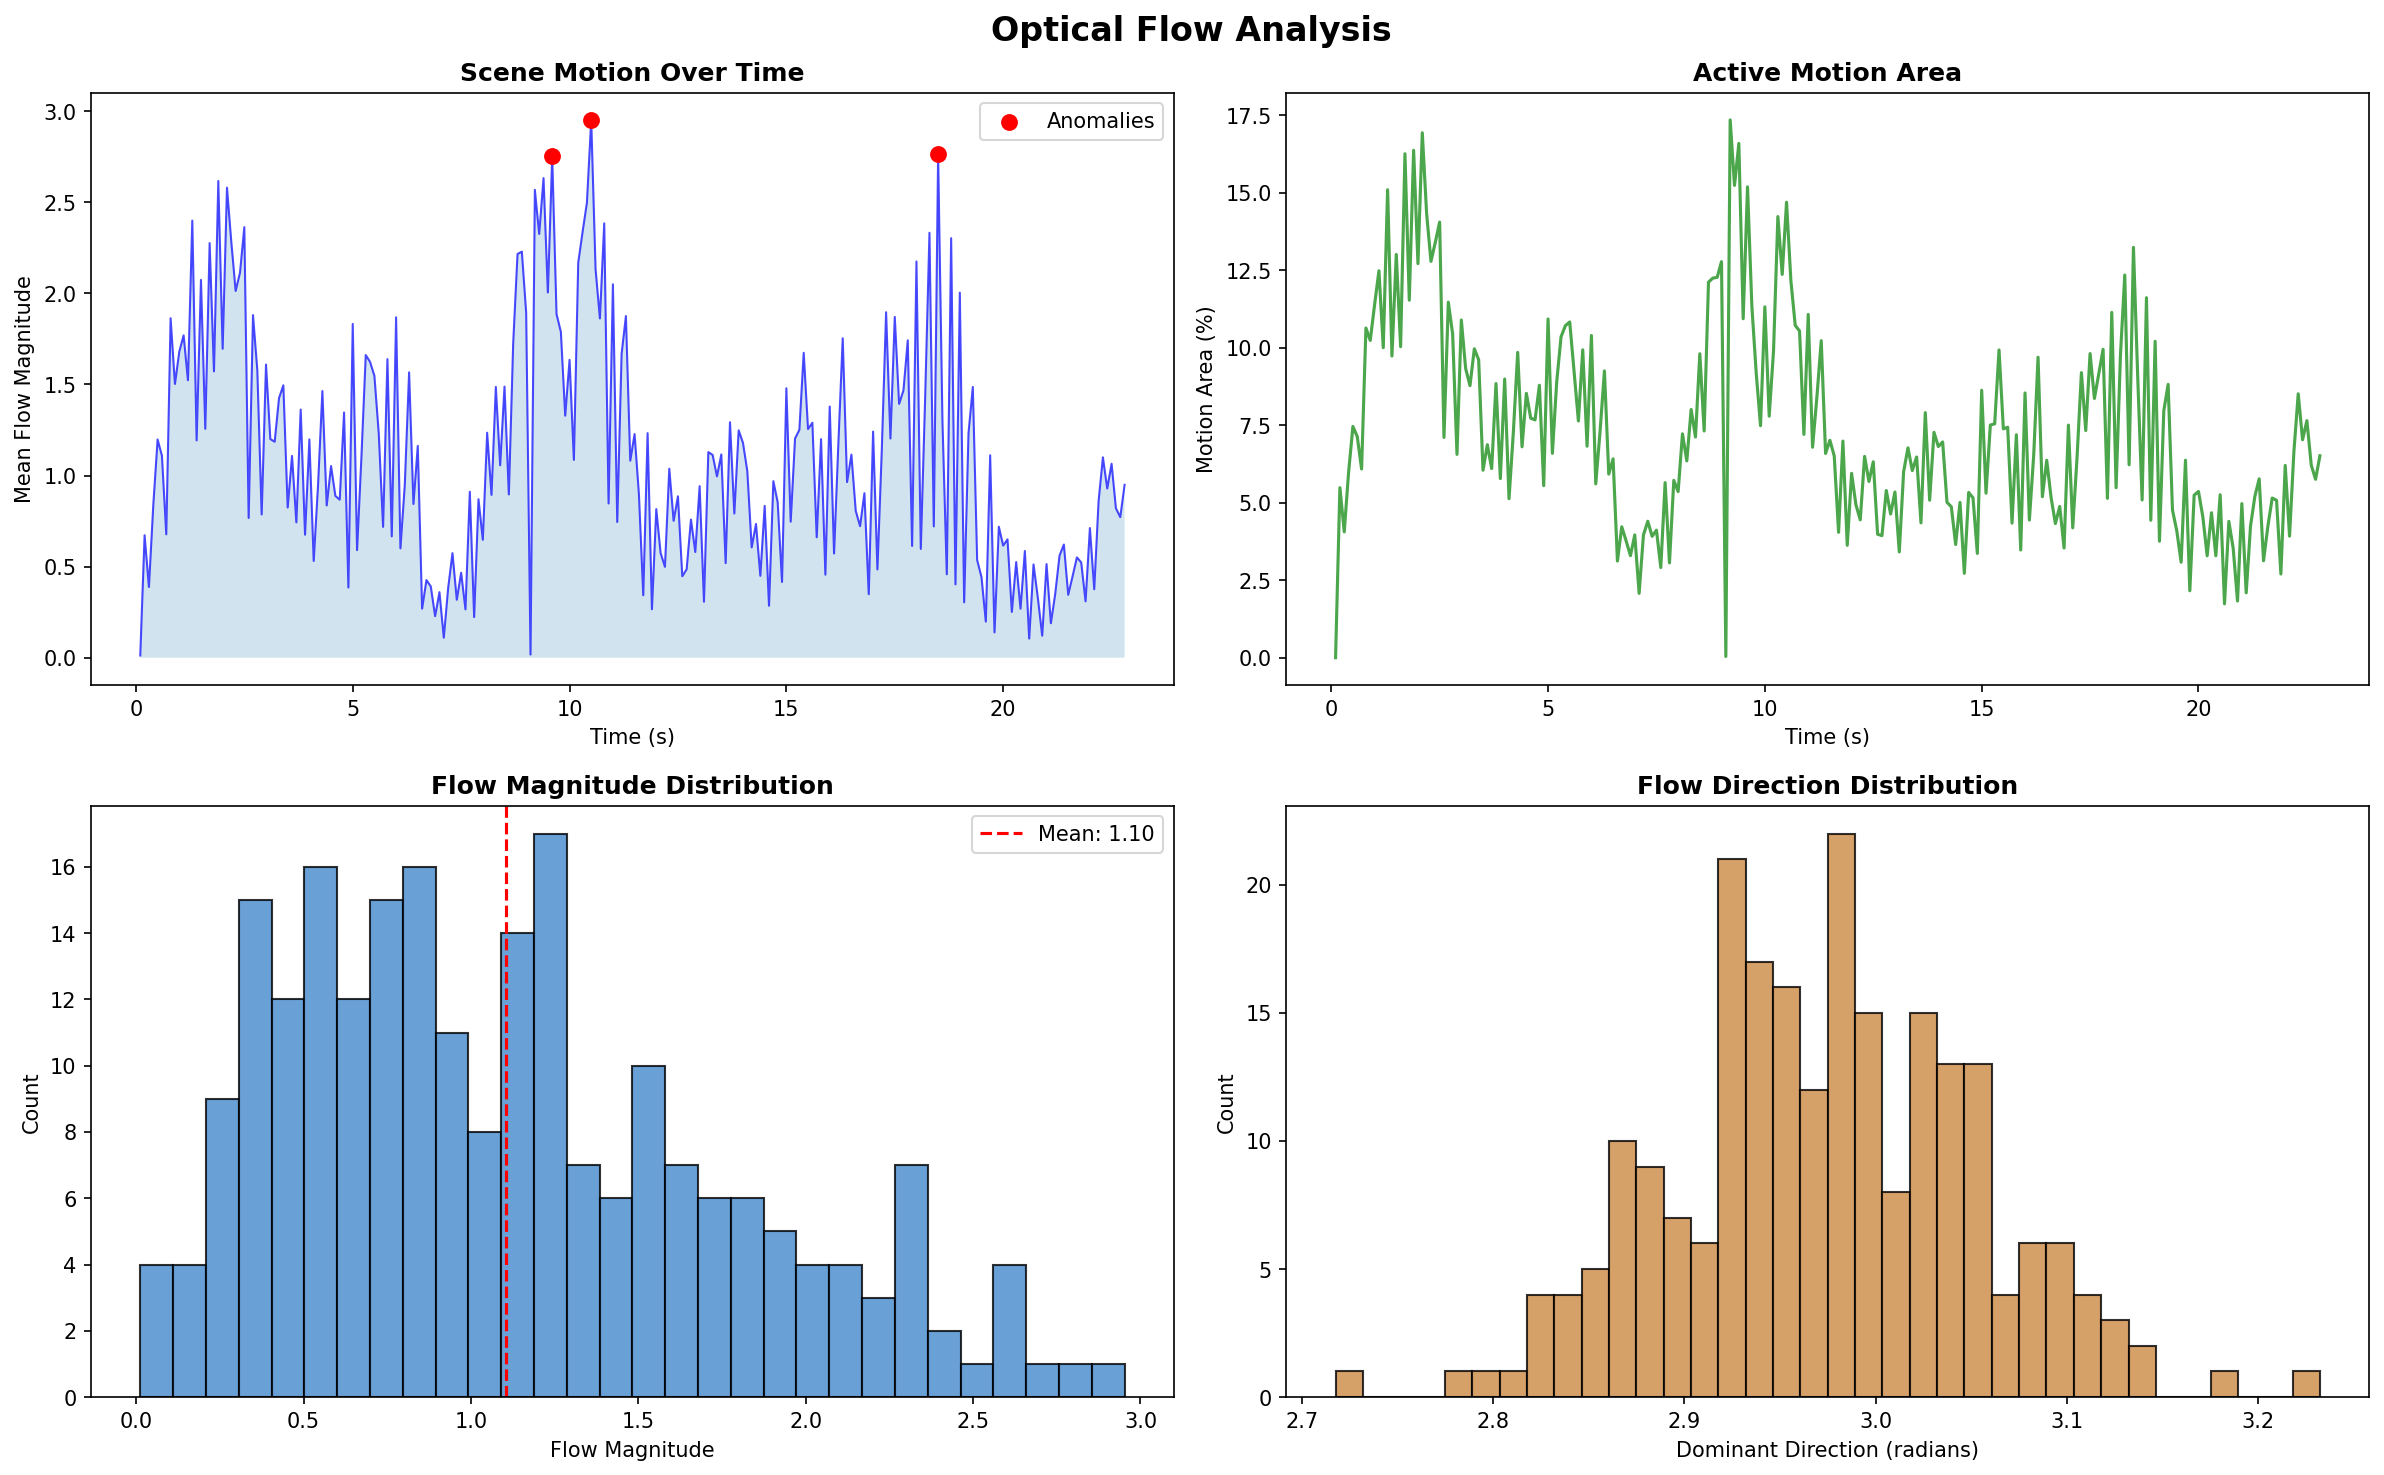

In [ ]:
# ════════════════════════════════════════════════════════
# 8.2  Optical Flow Dashboard
# ════════════════════════════════════════════════════════

dashboard_gen.create_flow_dashboard(
    flow_analyzer.scene_flow_stats,
    flow_anomalies,
    video_info
)

display(IPImage('../outputs/flow_dashboard.png'))

In [ ]:
# ════════════════════════════════════════════════════════
# 8.3  Multi-Class Interaction Analysis (Bonus)
# ════════════════════════════════════════════════════════

pair_counts = defaultdict(int)
pair_risk = defaultdict(list)

for inc in incidents:
    classes = sorted(list(inc.involved_classes))
    pair = ' ↔ '.join(classes)
    pair_counts[pair] += 1
    pair_risk[pair].append(inc.max_risk_score)

if pair_counts:
    fig, ax = plt.subplots(figsize=(10, 5))
    pairs = list(pair_counts.keys())
    counts = list(pair_counts.values())
    avg_risks = [np.mean(pair_risk[p]) for p in pairs]
    
    max_r = max(avg_risks) if max(avg_risks) > 0 else 1
    colors = plt.cm.RdYlGn_r(np.array(avg_risks) / max_r)
    
    ax.bar(pairs, counts, color=colors, edgecolor='black')
    ax.set_ylabel('Incident Count')
    ax.set_title('Near-Miss Incidents by Object Class Pair', fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('../outputs/class_pair_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

# Vulnerable user stats
vuln = [i for i in incidents if 'Pedestrian' in i.involved_classes or 'Cyclist' in i.involved_classes]
print(f'\nVulnerable road user incidents: {len(vuln)}/{len(incidents)} '
      f'({100*len(vuln)/max(1,len(incidents)):.0f}%)')


Vulnerable road user incidents: 0/6 (0%)


In [ ]:
# ════════════════════════════════════════════════════════
# 8.4  False Positive Reduction Report
# ════════════════════════════════════════════════════════

total_events = len(raw_events)
incident_events = sum(len(inc.events) for inc in incidents)
filtered = total_events - incident_events

print('False Positive Reduction Report')
print('=' * 50)
print(f'  Raw events:                {total_events}')
print(f'  Events in valid incidents: {incident_events}')
print(f'  Filtered out:             {filtered} ({100*filtered/max(1,total_events):.1f}%)')
print(f'  Final incidents:          {len(incidents)}')
print(f'\n  Filter layers:')
print(f'    1. Temporal: ≥{cfg.filter.min_incident_frames} consecutive frames')
print(f'    2. Area:    ≥{cfg.detection.min_object_area}px² bounding box')
print(f'    3. Merging: gap ≤{cfg.filter.merge_gap_frames} frames')

🔍 False Positive Reduction Report
  Raw events:                113
  Events in valid incidents: 111
  Filtered out:             2 (1.8%)
  Final incidents:          6

  Filter layers:
    1. Temporal: ≥3 consecutive frames
    2. Area:    ≥400px² bounding box
    3. Merging: gap ≤10 frames


<a id="9"></a>
---
## 9. Report Generation

In [32]:
import importlib
import src.report

importlib.reload(src.report)
from src.report import generate_html_report, export_json_results

In [33]:
# ════════════════════════════════════════════════════════
# 9.1  Generate HTML Report
# ════════════════════════════════════════════════════════

report_path = generate_html_report(
    incidents, raw_events, tracking_stats, video_info, cfg,
    flow_anomaly_count=len(flow_anomalies)
)

  ✅ Report saved: near_miss_report.html


In [ ]:
# ════════════════════════════════════════════════════════
# 9.2  Export JSON Results
# ════════════════════════════════════════════════════════

json_path = export_json_results(incidents, tracking_stats, video_info)

print(f'\nPipeline Complete!')
print(f'   Output files:')
print(f'   • {cfg.output_video}, Annotated video')
print(f'   • near_miss_report.html, HTML report')
print(f'   • dashboard.png, Analysis dashboard')
print(f'   • flow_dashboard.png, Optical flow analysis')
print(f'   • peak_moments.png, Peak risk moments')
print(f'   • class_pair_analysis.png, Class interaction chart')
print(f'   • analysis_results.json, Machine-readable results')

  ✅ JSON results saved: analysis_results.json

🎉 Pipeline Complete!
   Output files:
   • annotated_near_miss.mp4, Annotated video
   • near_miss_report.html, HTML report
   • dashboard.png, Analysis dashboard
   • flow_dashboard.png, Optical flow analysis
   • peak_moments.png, Peak risk moments
   • class_pair_analysis.png, Class interaction chart
   • analysis_results.json, Machine-readable results


<a id="10"></a>
---
## 10. Limitations & Future Work

### Known Limitations

1. **Pixel-based distance**: No camera calibration; pixel distances are approximate and affected by perspective distortion. Objects at different depths may appear closer in 2D than they are in 3D.

2. **Fixed thresholds**: Risk thresholds are manually calibrated for this specific video. A production system needs adaptive thresholds based on scene context and camera parameters.

3. **2D bounding boxes**: No depth estimation; objects at different distances can overlap in 2D, causing false positives.

4. **Constant acceleration model**: Kalman filter assumes smooth dynamics. Sudden, extreme maneuvers may lag behind the true state by 1-2 frames.

5. **Optical flow cost**: Dense flow computation adds ~30% to total processing time. In production, sparse flow or region-of-interest flow would be more efficient.

6. **Occlusion sensitivity**: Heavy occlusions or missed detections may break track continuity, affecting TTC estimation accuracy.

### Potential Improvements

1. **Camera calibration** → Map pixels to real-world meters using road markings as reference
2. **Monocular depth** (MiDaS) → Pseudo-3D positions from single camera
3. **RAFT optical flow** → More accurate flow at comparable speed
4. **Learned risk scoring** → Train classifier on labeled near-miss events
5. **INT8 quantization** → 2-3× speedup for real-time CPU processing
6. **Multi-camera fusion** → 3D reconstruction at intersections
7. **IMM Kalman filter** → Interacting Multiple Models for switching between constant velocity and constant turn rate
8. **Real-time deployment** → Integrate with streaming pipelines (e.g., RTSP + Kafka) for live traffic monitoring
